# Bot Round Analysis

In bot rounds, each human plays with 2 AI bots who stubbornly play fixed roles. The human's stat-optimal role differs from the deviate-optimal role — the question is whether humans learn to deviate.

**Three questions:**
1. What do humans actually do? Do they deviate to the optimal role?
2. Which computational models explain this behavior?
3. Why does Bayesian-Value — the model designed to capture value-optimal deviation — fail?

**Data:** 84 bot rounds, 42 players, 6 configs (March 6 + March 18 exports).

**Update (04-06):** Includes all 8 Bayesian models + 2 baselines with tuned parameters from Bhavyesh's analysis. Uses Bhavyesh's metrics (combo_r, marg_r, mean_ll) alongside accuracy/CE.

In [1]:
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path
from collections import defaultdict, Counter
from scipy.stats import pearsonr

matplotlib.rcParams['figure.dpi'] = 130
warnings.filterwarnings('ignore')

sys.path.insert(0, '/Users/jolow/coding/bayesian-role-specialization/analysis')
from shared import EXPORTS_DIR, DATA_ROOT
from shared.constants import (
    F, T, M, ROLE_NAMES, ROLE_SHORT, ROLE_CHAR_TO_IDX, GAME_ROLE_TO_IDX,
    ALL_ROLE_COMBOS, TURNS_PER_STAGE,
)
from shared.parsing import canonical_combo, get_canonical_combos
from shared.inference import (
    utility_based_prior, bayesian_update, preferred_action, game_step,
    softmax_role_dist, combo_marginal,
)
from shared.evaluation import run_predictions, compute_pearson, compute_log_likelihood, extract_metrics
from shared.data_loading import load_all_exports, to_dataframe
import re as _re

OMS_DIR = Path(DATA_ROOT).parent.parent / 'computational_model' / 'analysis'
sys.path.insert(0, str(OMS_DIR))
import online_model_sim as oms

EXPERIMENTS_DIR = Path('/Users/jolow/coding/bayesian-role-specialization/analysis/experiments')
OUT_DIR = EXPERIMENTS_DIR / '2026-04-06-bot-round-analysis'

print("Imports OK")

Imports OK


In [2]:
# === Load data ===
DATA_DIRS = [
    EXPORTS_DIR / 'bayesian-role-specialization-2026-03-06-09-54-19',
    EXPORTS_DIR / 'bayesian-role-specialization-2026-03-18-15-47-09',
]
all_records = load_all_exports(data_dirs=DATA_DIRS, include_bot_rounds=True)
bot_records = [pr for pr in all_records if pr.round.round_type == "bot"]

# === Convert bot rounds to team-round dict format ===
def load_bot_env_config(config):
    env_id = str(config.get('envId', ''))
    env_dir = DATA_ROOT / 'envs' / env_id
    text = (env_dir / 'config.py').read_text()
    team_max_hp = int(_re.search(r'TEAM_MAX_HP\s*=\s*(\d+)', text).group(1))
    enemy_max_hp = int(_re.search(r'ENEMY_MAX_HP\s*=\s*(\d+)', text).group(1))
    boss_damage = float(_re.search(r'BOSS_DAMAGE\s*=\s*([\d.]+)', text).group(1))
    ps_match = _re.search(r'PLAYER_STATS\s*=\s*(?:jnp\.array|np\.array)?\(?\s*(\[\[.+?\]\])\s*\)?', text, _re.DOTALL)
    rows = _re.findall(r'\[([^\[\]]+)\]', ps_match.group(1))
    player_stats = np.array([[float(x) for x in row.split(',')] for row in rows])
    values = np.load(env_dir / 'values.npy')
    return {'values': values, 'player_stats': player_stats, 'boss_damage': boss_damage,
            'team_max_hp': team_max_hp, 'enemy_max_hp': enemy_max_hp}

env_configs_cache = {}
bot_team_records = []
for pr in bot_records:
    rnd = pr.round
    config = rnd.config
    odr_id = rnd.optimal_deviate_roles_id
    human_pos = config.get('humanRole', 0)
    bot_players = config.get('botPlayers', [])
    bot_positions = [p for p in range(3) if p != human_pos]
    bot_fixed_roles = {bot_positions[i]: bp['strategy']['role'] for i, bp in enumerate(bot_players)}
    stage_roles = []
    for stg in rnd.stages:
        combo = [''] * 3
        combo[human_pos] = ROLE_SHORT[stg.role_idx]
        for pos, role_idx in bot_fixed_roles.items():
            combo[pos] = ROLE_SHORT[role_idx]
        stage_roles.append(''.join(combo))
    eis = rnd.enemy_intent_sequence
    lds = []
    for stg in rnd.stages:
        for turn in stg.turns:
            ti = turn.get('turn', 0)
            lds.append(int(eis[ti]) if ti < len(eis) else 0)
    eid = str(config.get('envId', ''))
    if eid not in env_configs_cache:
        env_configs_cache[eid] = load_bot_env_config(config)
    bot_team_records.append({
        'env_id': odr_id, 'stat_profile': rnd.stat_profile_id,
        'optimal_roles': ''.join(ROLE_SHORT[i] for i in rnd.optimal_roles),
        'stage_roles': stage_roles, 'lds': lds, 'env_config': env_configs_cache[eid],
        'human_position': human_pos, 'bot_fixed_roles': bot_fixed_roles,
        'odr_id': odr_id, 'participant_id': pr.participant_id, 'outcome': rnd.outcome,
    })

# === Load human round records ===
oms.VALUE_MATRICES_DIR = DATA_ROOT / 'human_envs_value_matrices'
oms.ENVS_DIR = DATA_ROOT / 'envs'
def _load_config_no_jax(config_path):
    text = Path(config_path).read_text()
    team_max_hp = int(_re.search(r'TEAM_MAX_HP\s*=\s*(\d+)', text).group(1))
    enemy_max_hp = int(_re.search(r'ENEMY_MAX_HP\s*=\s*(\d+)', text).group(1))
    boss_damage = float(_re.search(r'BOSS_DAMAGE\s*=\s*([\d.]+)', text).group(1))
    ps_match = _re.search(r'PLAYER_STATS\s*=\s*(?:jnp\.array|np\.array)?\(?\s*(\[\[.+?\]\])\s*\)?', text, _re.DOTALL)
    rows = _re.findall(r'\[([^\[\]]+)\]', ps_match.group(1))
    player_stats = np.array([[float(x) for x in row.split(',')] for row in rows])
    class Config: pass
    cfg = Config()
    cfg.TEAM_MAX_HP, cfg.ENEMY_MAX_HP, cfg.BOSS_DAMAGE, cfg.PLAYER_STATS = team_max_hp, enemy_max_hp, boss_damage, player_stats
    return cfg
oms.load_config_module = _load_config_no_jax
human_team_records = oms.load_team_rounds(data_dirs=[str(d) for d in DATA_DIRS])

# === Load tuned parameters ===
PS_DIR = EXPERIMENTS_DIR / '2026-03-31-walk-thresh-ps'
VALUE_DIR = EXPERIMENTS_DIR / '2026-03-29-new-models-all-data'
BB_DIR = EXPERIMENTS_DIR / '2026-04-06-bayesian-belief'
def load_params(path):
    with open(path) as f: return json.load(f)

params = {
    'bb': load_params(BB_DIR / 'bayesian_belief/bayesian_belief_params.json'),
    'bwps': load_params(PS_DIR / 'bayesian_walk_ps/bayesian_walk_ps_params.json'),
    'btps': load_params(PS_DIR / 'bayesian_thresh_ps/bayesian_thresh_ps_params.json'),
    'mps': load_params(PS_DIR / 'mixture_ps/mixture_ps_params.json'),
    'bw': load_params(VALUE_DIR / 'bayesian_walk/bayesian_walk_params.json'),
    'bt': load_params(VALUE_DIR / 'bayesian_thresh/bayesian_thresh_params.json'),
    'bv': load_params(VALUE_DIR / 'bayesian_value/bayesian_value_params.json'),
    'rw': load_params(VALUE_DIR / 'random_walk/random_walk_params.json'),
}

print(f"Loaded {len(bot_team_records)} bot rounds, {len(human_team_records)} human team-rounds")

Loaded bayesian-role-specialization-2026-03-06-09-54-19: 96 player-rounds
Loaded bayesian-role-specialization-2026-03-18-15-47-09: 240 player-rounds
Total: 336 player-rounds from 2 exports
Loaded 84 bot rounds, 66 human team-rounds


In [3]:
# === Define all models ===

def posterior_marginal(prior, agent_i):
    marg = np.sum(prior, axis=tuple(j for j in range(3) if j != agent_i))
    total = marg.sum()
    return marg / total if total > 0 else np.ones(3) / 3.0

# --- PS Models ---
def make_bayesian_walk_ps(tau_prior, epsilon, epsilon_switch):
    def predict_fn(record):
        env = record['env_config']
        ps, bd = env['player_stats'], env['boss_damage']
        tmhp, emhp = env['team_max_hp'], env['enemy_max_hp']
        thp, ehp, prior = float(tmhp), float(emhp), utility_based_prior(ps, tau=tau_prior)
        results, turn_idx, prev_roles = [], 0, None
        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or thp <= 0 or ehp <= 0: break
            per_agent = []
            for i in range(3):
                sd = posterior_marginal(prior, i)
                if prev_roles is None: per_agent.append(sd)
                else:
                    stick = np.zeros(3); stick[prev_roles[i]] = 1.0
                    per_agent.append((1-epsilon_switch)*stick + epsilon_switch*sd)
            pd = {}
            for r0 in range(3):
                for r1 in range(3):
                    for r2 in range(3):
                        pd[ROLE_SHORT[r0]+ROLE_SHORT[r1]+ROLE_SHORT[r2]] = float(per_agent[0][r0]*per_agent[1][r1]*per_agent[2][r2])
            results.append({'predicted_dist': pd, 'human_combo': human_combo, 'model_marginal': np.mean(per_agent, axis=0)})
            hr = [ROLE_CHAR_TO_IDX[c] for c in human_combo]; prev_roles = hr
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or thp <= 0 or ehp <= 0: break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(hr[i], intent, thp, tmhp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, thp, tmhp, epsilon)
                thp, ehp = game_step(intent, thp, ehp, actions, ps, bd, tmhp); turn_idx += 1
        return results
    return predict_fn

def make_bayesian_thresh_ps(tau_prior, epsilon, delta):
    def predict_fn(record):
        env = record['env_config']
        ps, bd = env['player_stats'], env['boss_damage']
        tmhp, emhp = env['team_max_hp'], env['enemy_max_hp']
        thp, ehp, prior = float(tmhp), float(emhp), utility_based_prior(ps, tau=tau_prior)
        results, turn_idx, prev_roles = [], 0, None
        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or thp <= 0 or ehp <= 0: break
            per_agent = []
            for i in range(3):
                if prev_roles is None: per_agent.append(posterior_marginal(prior, i))
                else:
                    marg = posterior_marginal(prior, i)
                    cp = marg[prev_roles[i]]
                    cands = [r for r in range(3) if r != prev_roles[i] and (marg[r]-cp) > delta]
                    if not cands: d = np.zeros(3); d[prev_roles[i]] = 1.0
                    else:
                        cp2 = np.array([marg[r] for r in cands]); cp2 /= cp2.sum()
                        d = np.zeros(3)
                        for j, r in enumerate(cands): d[r] = cp2[j]
                    per_agent.append(d)
            pd = {}
            for r0 in range(3):
                for r1 in range(3):
                    for r2 in range(3):
                        pd[ROLE_SHORT[r0]+ROLE_SHORT[r1]+ROLE_SHORT[r2]] = float(per_agent[0][r0]*per_agent[1][r1]*per_agent[2][r2])
            results.append({'predicted_dist': pd, 'human_combo': human_combo, 'model_marginal': np.mean(per_agent, axis=0)})
            hr = [ROLE_CHAR_TO_IDX[c] for c in human_combo]; prev_roles = hr
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or thp <= 0 or ehp <= 0: break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(hr[i], intent, thp, tmhp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, thp, tmhp, epsilon)
                thp, ehp = game_step(intent, thp, ehp, actions, ps, bd, tmhp); turn_idx += 1
        return results
    return predict_fn

def make_mixture_ps(tau_prior, epsilon, epsilon_switch, delta, w):
    def predict_fn(record):
        env = record['env_config']
        ps, bd = env['player_stats'], env['boss_damage']
        tmhp, emhp = env['team_max_hp'], env['enemy_max_hp']
        thp, ehp, prior = float(tmhp), float(emhp), utility_based_prior(ps, tau=tau_prior)
        results, turn_idx, prev_roles = [], 0, None
        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or thp <= 0 or ehp <= 0: break
            per_agent = []
            for i in range(3):
                marg = posterior_marginal(prior, i)
                pr = prev_roles[i] if prev_roles else None
                if pr is None: d_walk = marg
                else: s = np.zeros(3); s[pr] = 1.0; d_walk = (1-epsilon_switch)*s + epsilon_switch*marg
                if pr is None: d_thresh = marg
                else:
                    cp = marg[pr]; cands = [r for r in range(3) if r != pr and (marg[r]-cp) > delta]
                    if not cands: d_thresh = np.zeros(3); d_thresh[pr] = 1.0
                    else:
                        cp2 = np.array([marg[r] for r in cands]); cp2 /= cp2.sum()
                        d_thresh = np.zeros(3)
                        for j, r in enumerate(cands): d_thresh[r] = cp2[j]
                per_agent.append(w*d_walk + (1-w)*d_thresh)
            pd = {}
            for r0 in range(3):
                for r1 in range(3):
                    for r2 in range(3):
                        pd[ROLE_SHORT[r0]+ROLE_SHORT[r1]+ROLE_SHORT[r2]] = float(per_agent[0][r0]*per_agent[1][r1]*per_agent[2][r2])
            results.append({'predicted_dist': pd, 'human_combo': human_combo, 'model_marginal': np.mean(per_agent, axis=0)})
            hr = [ROLE_CHAR_TO_IDX[c] for c in human_combo]; prev_roles = hr
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or thp <= 0 or ehp <= 0: break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(hr[i], intent, thp, tmhp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, thp, tmhp, epsilon)
                thp, ehp = game_step(intent, thp, ehp, actions, ps, bd, tmhp); turn_idx += 1
        return results
    return predict_fn

# --- Value-Based Models ---
def make_bayesian_walk(tau_prior, tau_softmax, epsilon, epsilon_switch):
    def predict_fn(record):
        env = record['env_config']
        values, ps, bd = env['values'], env['player_stats'], env['boss_damage']
        tmhp, emhp = env['team_max_hp'], env['enemy_max_hp']
        thp, ehp, prior = float(tmhp), float(emhp), utility_based_prior(ps, tau=tau_prior)
        results, turn_idx, prev_roles = [], 0, None
        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or thp <= 0 or ehp <= 0: break
            intent = record['lds'][turn_idx]
            ti, ei = int(min(max(0,thp),tmhp)), int(min(max(0,ehp),emhp))
            per_agent = []
            for i in range(3):
                sd = softmax_role_dist(i, intent, ti, ei, prior, values, tau_softmax)
                if prev_roles is None: per_agent.append(sd)
                else:
                    s = np.zeros(3); s[prev_roles[i]] = 1.0
                    per_agent.append((1-epsilon_switch)*s + epsilon_switch*sd)
            pd = {}
            for r0 in range(3):
                for r1 in range(3):
                    for r2 in range(3):
                        pd[ROLE_SHORT[r0]+ROLE_SHORT[r1]+ROLE_SHORT[r2]] = float(per_agent[0][r0]*per_agent[1][r1]*per_agent[2][r2])
            results.append({'predicted_dist': pd, 'human_combo': human_combo, 'model_marginal': np.mean(per_agent, axis=0)})
            hr = [ROLE_CHAR_TO_IDX[c] for c in human_combo]; prev_roles = hr
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or thp <= 0 or ehp <= 0: break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(hr[i], intent, thp, tmhp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, thp, tmhp, epsilon)
                thp, ehp = game_step(intent, thp, ehp, actions, ps, bd, tmhp); turn_idx += 1
        return results
    return predict_fn

def make_bayesian_value(tau_prior, tau_softmax, epsilon):
    def predict_fn(record):
        env = record['env_config']
        values, ps, bd = env['values'], env['player_stats'], env['boss_damage']
        tmhp, emhp = env['team_max_hp'], env['enemy_max_hp']
        thp, ehp, prior = float(tmhp), float(emhp), utility_based_prior(ps, tau=tau_prior)
        results, turn_idx = [], 0
        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or thp <= 0 or ehp <= 0: break
            intent = record['lds'][turn_idx]
            ti, ei = int(min(max(0,thp),tmhp)), int(min(max(0,ehp),emhp))
            per_agent = [softmax_role_dist(i, intent, ti, ei, prior, values, tau_softmax) for i in range(3)]
            pd = {}
            for r0 in range(3):
                for r1 in range(3):
                    for r2 in range(3):
                        pd[ROLE_SHORT[r0]+ROLE_SHORT[r1]+ROLE_SHORT[r2]] = float(per_agent[0][r0]*per_agent[1][r1]*per_agent[2][r2])
            results.append({'predicted_dist': pd, 'human_combo': human_combo, 'model_marginal': np.mean(per_agent, axis=0)})
            hr = [ROLE_CHAR_TO_IDX[c] for c in human_combo]
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or thp <= 0 or ehp <= 0: break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(hr[i], intent, thp, tmhp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, thp, tmhp, epsilon)
                thp, ehp = game_step(intent, thp, ehp, actions, ps, bd, tmhp); turn_idx += 1
        return results
    return predict_fn

def make_bayesian_belief(tau_prior, epsilon):
    def predict_fn(record):
        env = record['env_config']
        ps, bd = env['player_stats'], env['boss_damage']
        tmhp, emhp = env['team_max_hp'], env['enemy_max_hp']
        thp, ehp, prior = float(tmhp), float(emhp), utility_based_prior(ps, tau=tau_prior)
        results, turn_idx = [], 0
        for human_combo in record['stage_roles']:
            if turn_idx >= len(record['lds']) or thp <= 0 or ehp <= 0: break
            per_agent = [posterior_marginal(prior, i) for i in range(3)]
            pd = {}
            for r0 in range(3):
                for r1 in range(3):
                    for r2 in range(3):
                        pd[ROLE_SHORT[r0]+ROLE_SHORT[r1]+ROLE_SHORT[r2]] = float(per_agent[0][r0]*per_agent[1][r1]*per_agent[2][r2])
            results.append({'predicted_dist': pd, 'human_combo': human_combo, 'model_marginal': np.mean(per_agent, axis=0)})
            hr = [ROLE_CHAR_TO_IDX[c] for c in human_combo]
            for _ in range(TURNS_PER_STAGE):
                if turn_idx >= len(record['lds']) or thp <= 0 or ehp <= 0: break
                intent = record['lds'][turn_idx]
                actions = [preferred_action(hr[i], intent, thp, tmhp) for i in range(3)]
                prior = bayesian_update(prior, actions, intent, thp, tmhp, epsilon)
                thp, ehp = game_step(intent, thp, ehp, actions, ps, bd, tmhp); turn_idx += 1
        return results
    return predict_fn

# --- Baselines ---
def run_baseline(records, predict_fn):
    def wrapped(record):
        preds = []
        for s, hc in enumerate(record['stage_roles']):
            prev = record['stage_roles'][s-1] if s > 0 else None
            dist = predict_fn(record, s, prev, record['env_config'])
            marg = np.zeros(3)
            for combo, prob in dist.items():
                for c in combo: marg[ROLE_CHAR_TO_IDX[c]] += prob
            marg /= 3.0
            preds.append({'predicted_dist': dist, 'human_combo': hc, 'model_marginal': marg})
        return preds
    return run_predictions(records, wrapped)

def make_random_walk(eps):
    def predict(record, stage_idx, prev_combo, env_config):
        if prev_combo is None: return {c: 1.0/27 for c in ALL_ROLE_COMBOS}
        dist = {}
        for combo in ALL_ROLE_COMBOS:
            p = 1.0
            for i, (c, pc) in enumerate(zip(combo, prev_combo)):
                p *= (1-eps) if c == pc else (eps/2)
            dist[combo] = p
        total = sum(dist.values())
        return {c: p/total for c, p in dist.items()}
    return predict

def predict_random(record, stage_idx, prev_combo, env_config):
    return {c: 1.0/27 for c in ALL_ROLE_COMBOS}

print("All models defined")

All models defined


In [4]:
# === Evaluation functions ===

env_human_pos = {r['env_id']: r['human_position'] for r in bot_team_records}

def eval_bot(results, bot_team_records):
    """Per-observation top-1 accuracy and cross-entropy for the human player only."""
    correct, total, ces = 0, 0, []
    for env_id, data in results.items():
        hp = env_human_pos.get(env_id, 0)
        for team_preds in data['team_predictions']:
            for pred in team_preds:
                hm = np.zeros(3)
                for combo, prob in pred['predicted_dist'].items():
                    hm[ROLE_CHAR_TO_IDX[combo[hp]]] += prob
                t = hm.sum()
                if t > 0: hm /= t
                actual = ROLE_CHAR_TO_IDX[pred['human_combo'][hp]]
                if np.argmax(hm) == actual: correct += 1
                total += 1
                ces.append(-np.log(max(hm[actual], 1e-20)))
    return correct/total, np.mean(ces), total

def eval_human(results):
    """Per-observation top-1 accuracy and cross-entropy, all 3 players."""
    correct, total, ces = 0, 0, []
    for env_id, data in results.items():
        for team_preds in data['team_predictions']:
            for pred in team_preds:
                for pos in range(3):
                    hm = np.zeros(3)
                    for combo, prob in pred['predicted_dist'].items():
                        hm[ROLE_CHAR_TO_IDX[combo[pos]]] += prob
                    t = hm.sum()
                    if t > 0: hm /= t
                    actual = ROLE_CHAR_TO_IDX[pred['human_combo'][pos]]
                    if np.argmax(hm) == actual: correct += 1
                    total += 1
                    ces.append(-np.log(max(hm[actual], 1e-20)))
    return correct/total, np.mean(ces), total

def compute_bot_marg_r(bot_results, bot_team_records):
    """Pearson r between model-predicted and observed human role marginals."""
    env_hp = {r['env_id']: r['human_position'] for r in bot_team_records}
    pred_vec, obs_vec = [], []
    for env_id, data in bot_results.items():
        hp = env_hp.get(env_id, 0)
        stage_model = defaultdict(lambda: np.zeros(3))
        stage_obs = defaultdict(lambda: np.zeros(3))
        stage_n = defaultdict(int)
        for team_preds in data['team_predictions']:
            for s, pred in enumerate(team_preds):
                hm = np.zeros(3)
                for combo, prob in pred['predicted_dist'].items():
                    hm[ROLE_CHAR_TO_IDX[combo[hp]]] += prob
                t = hm.sum()
                if t > 0: hm /= t
                stage_model[s] += hm
                actual = ROLE_CHAR_TO_IDX[pred['human_combo'][hp]]
                obs = np.zeros(3); obs[actual] = 1.0
                stage_obs[s] += obs
                stage_n[s] += 1
        for s in sorted(stage_n.keys()):
            n = stage_n[s]
            if n > 0:
                pred_vec.extend((stage_model[s] / n).tolist())
                obs_vec.extend((stage_obs[s] / n).tolist())
    if len(pred_vec) >= 2:
        r, p = pearsonr(pred_vec, obs_vec)
        return float(r), float(p), len(pred_vec)
    return float('nan'), float('nan'), 0

def compute_bot_mean_ll(bot_results, bot_team_records):
    """Mean log-likelihood for the human player only in bot rounds."""
    env_hp = {r['env_id']: r['human_position'] for r in bot_team_records}
    lls = []
    for env_id, data in bot_results.items():
        hp = env_hp.get(env_id, 0)
        for team_preds in data['team_predictions']:
            for pred in team_preds:
                hm = np.zeros(3)
                for combo, prob in pred['predicted_dist'].items():
                    hm[ROLE_CHAR_TO_IDX[combo[hp]]] += prob
                t = hm.sum()
                if t > 0: hm /= t
                actual = ROLE_CHAR_TO_IDX[pred['human_combo'][hp]]
                lls.append(np.log(max(hm[actual], 1e-20)))
    return np.mean(lls) if lls else float('nan')

print("Evaluation functions defined")

Evaluation functions defined


In [8]:
# === Run all models on both datasets ===
p = params
bb = p['bb']['aggregate_tuned']
bt_p = p['bt']['aggregate_tuned']['bayesian_thresh']

model_specs = [
    ('Bayesian Walk (BR)',    lambda: run_predictions(bot_team_records, make_bayesian_walk(p['bw']['aggregate_tuned']['tau_prior'], p['bw']['aggregate_tuned']['tau_softmax'], p['bw']['aggregate_tuned']['epsilon'], p['bw']['aggregate_tuned']['epsilon_switch'])),
                              lambda: run_predictions(human_team_records, make_bayesian_walk(p['bw']['aggregate_tuned']['tau_prior'], p['bw']['aggregate_tuned']['tau_softmax'], p['bw']['aggregate_tuned']['epsilon'], p['bw']['aggregate_tuned']['epsilon_switch']))),
    ('Mixture PS',            lambda: run_predictions(bot_team_records, make_mixture_ps(p['mps']['aggregate_tuned']['tau_prior'], p['mps']['aggregate_tuned']['epsilon'], p['mps']['aggregate_tuned']['epsilon_switch'], p['mps']['aggregate_tuned']['delta'], p['mps']['aggregate_tuned']['w'])),
                              lambda: run_predictions(human_team_records, make_mixture_ps(p['mps']['aggregate_tuned']['tau_prior'], p['mps']['aggregate_tuned']['epsilon'], p['mps']['aggregate_tuned']['epsilon_switch'], p['mps']['aggregate_tuned']['delta'], p['mps']['aggregate_tuned']['w']))),
    ('Bayesian Walk PS',      lambda: run_predictions(bot_team_records, make_bayesian_walk_ps(p['bwps']['aggregate_tuned']['tau_prior'], p['bwps']['aggregate_tuned']['epsilon'], p['bwps']['aggregate_tuned']['epsilon_switch'])),
                              lambda: run_predictions(human_team_records, make_bayesian_walk_ps(p['bwps']['aggregate_tuned']['tau_prior'], p['bwps']['aggregate_tuned']['epsilon'], p['bwps']['aggregate_tuned']['epsilon_switch']))),
    ('Bayesian Thresh PS',    lambda: run_predictions(bot_team_records, make_bayesian_thresh_ps(p['btps']['aggregate_tuned']['tau_prior'], p['btps']['aggregate_tuned']['epsilon'], p['btps']['aggregate_tuned']['delta'])),
                              lambda: run_predictions(human_team_records, make_bayesian_thresh_ps(p['btps']['aggregate_tuned']['tau_prior'], p['btps']['aggregate_tuned']['epsilon'], p['btps']['aggregate_tuned']['delta']))),
    ('Bayesian-Belief',       lambda: run_predictions(bot_team_records, make_bayesian_belief(bb['tau_prior'], bb['epsilon'])),
                              lambda: run_predictions(human_team_records, make_bayesian_belief(bb['tau_prior'], bb['epsilon']))),
    ('Bayesian-Value',        lambda: run_predictions(bot_team_records, make_bayesian_value(p['bv']['aggregate_tuned']['tau_prior'], p['bv']['aggregate_tuned']['tau_softmax'], p['bv']['aggregate_tuned']['epsilon'])),
                              lambda: run_predictions(human_team_records, make_bayesian_value(p['bv']['aggregate_tuned']['tau_prior'], p['bv']['aggregate_tuned']['tau_softmax'], p['bv']['aggregate_tuned']['epsilon']))),
    ('Bayesian Thresh (BR)',  lambda: run_predictions(bot_team_records, make_bayesian_value(bt_p['tau_prior'], bt_p['tau_softmax'], bt_p['epsilon'])),
                              lambda: run_predictions(human_team_records, make_bayesian_value(bt_p['tau_prior'], bt_p['tau_softmax'], bt_p['epsilon']))),
    ('Random Walk',           lambda: run_baseline(bot_team_records, make_random_walk(p['rw']['aggregate_tuned']['eps'])),
                              lambda: run_baseline(human_team_records, make_random_walk(p['rw']['aggregate_tuned']['eps']))),
    ('Random',                lambda: run_baseline(bot_team_records, predict_random),
                              lambda: run_baseline(human_team_records, predict_random)),
]

def compute_global_mean_ll(results):
    """Compute global mean log-likelihood from run_predictions output."""
    lls = []
    for env_id, data in results.items():
        for team_preds in data['team_predictions']:
            for pred in team_preds:
                prob = pred['predicted_dist'].get(pred['human_combo'], 1e-20)
                lls.append(np.log(max(prob, 1e-20)))
    return np.mean(lls) if lls else float('nan')

results_table = []
for name, bot_fn, hum_fn in model_specs:
    print(f"Running {name}...")
    bot_res = bot_fn()
    hum_res = hum_fn()
    bot_acc, bot_ce, bot_n = eval_bot(bot_res, bot_team_records)
    hum_acc, hum_ce, hum_n = eval_human(hum_res)
    bot_mr, _, _ = compute_bot_marg_r(bot_res, bot_team_records)
    bot_ll = compute_bot_mean_ll(bot_res, bot_team_records)
    
    # Human marg_r and mean_ll
    hum_corrs = compute_pearson(hum_res)
    hum_mr = hum_corrs['__global__'].get('marginal', {}).get('r', float('nan'))
    hum_mean_ll = compute_global_mean_ll(hum_res)
    
    results_table.append({
        'Model': name,
        'bot_acc': bot_acc, 'bot_ce': bot_ce, 'bot_n': bot_n, 'bot_marg_r': bot_mr, 'bot_mean_ll': bot_ll,
        'hum_acc': hum_acc, 'hum_ce': hum_ce, 'hum_n': hum_n, 'hum_marg_r': hum_mr, 'hum_mean_ll': hum_mean_ll,
        'bot_results': bot_res,
    })

print("Done.")

Running Bayesian Walk (BR)...
Running Mixture PS...
Running Bayesian Walk PS...
Running Bayesian Thresh PS...


Running Bayesian-Belief...
Running Bayesian-Value...
Running Bayesian Thresh (BR)...
Running Random Walk...


Running Random...
Done.


## 1. What do humans actually do in bot rounds?

Each human has a **stat-optimal** role (suggested by their stats) and a **deviate-optimal** role (the true optimal given fixed bot teammates). Do they learn to deviate?

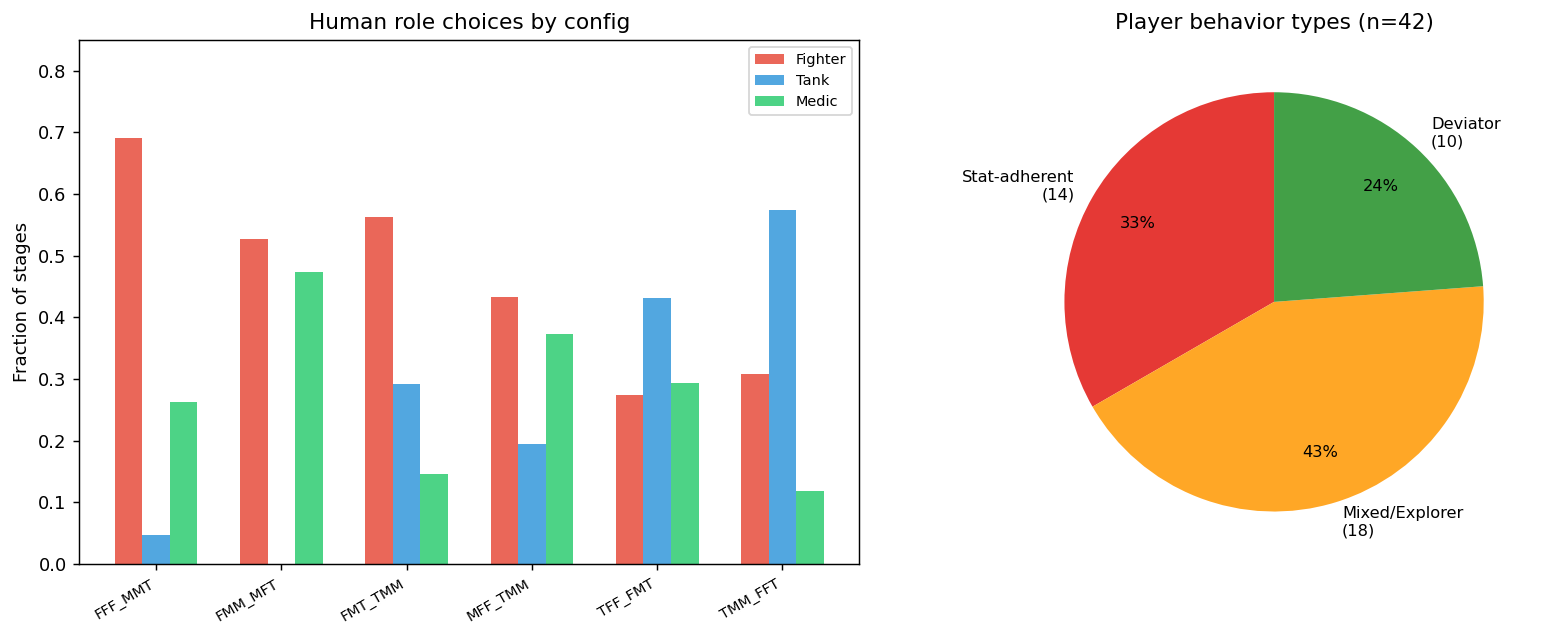


Overall: 52% stat-optimal, 30% deviate-optimal, 18% other


In [6]:
# === Figure 1: Human behavior in bot rounds ===

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: role choices per config ---
ax = axes[0]
configs = sorted(set(r['env_id'] for r in bot_team_records))
bar_width = 0.22
x = np.arange(len(configs))

for role_idx, (role_char, color) in enumerate(zip(['F', 'T', 'M'], ['#e74c3c', '#3498db', '#2ecc71'])):
    fracs = []
    for odr_id in configs:
        recs = [r for r in bot_team_records if r['env_id'] == odr_id]
        hp = recs[0]['human_position']
        roles = [combo[hp] for r in recs for combo in r['stage_roles']]
        fracs.append(roles.count(role_char) / len(roles))
    ax.bar(x + role_idx * bar_width, fracs, bar_width, color=color, label=f'{ROLE_NAMES[role_idx]}', alpha=0.85)

for i, odr_id in enumerate(configs):
    stat_opt, dev_opt = odr_id.split('_')
    ax.annotate(f'stat:{stat_opt[0]}', xy=(i + 0.22, -0.08), fontsize=7, ha='center', color='#555')
    ax.annotate(f'dev:{dev_opt[0]}', xy=(i + 0.22, -0.14), fontsize=7, ha='center', color='#007700')

ax.set_xticks(x + bar_width)
ax.set_xticklabels(configs, fontsize=8, rotation=30, ha='right')
ax.set_ylabel('Fraction of stages')
ax.set_title('Human role choices by config')
ax.legend(fontsize=8)
ax.set_ylim(0, 0.85)

# --- Right: per-player categorization ---
ax = axes[1]
all_pids = sorted(set(r['participant_id'] for r in bot_team_records))
player_data = []
for pid in all_pids:
    recs = [r for r in bot_team_records if r['participant_id'] == pid]
    n_dev, n_stat, n_total = 0, 0, 0
    for r in recs:
        stat_opt = r['odr_id'].split('_')[0][0]
        dev_opt = r['odr_id'].split('_')[1][0]
        hp = r['human_position']
        for combo in r['stage_roles']:
            h = combo[hp]; n_total += 1
            if h == dev_opt: n_dev += 1
            if h == stat_opt: n_stat += 1
    player_data.append({'pid': pid, 'dev_rate': n_dev/n_total, 'stat_rate': n_stat/n_total})

pdf = pd.DataFrame(player_data)
def categorize(row):
    if row['stat_rate'] >= 0.7: return 'Stat-adherent'
    elif row['dev_rate'] >= 0.5: return 'Deviator'
    else: return 'Mixed/Explorer'
pdf['type'] = pdf.apply(categorize, axis=1)

cats = ['Stat-adherent', 'Mixed/Explorer', 'Deviator']
cat_colors = ['#E53935', '#FFA726', '#43A047']
cat_counts = [len(pdf[pdf['type']==c]) for c in cats]

wedges, texts, autotexts = ax.pie(cat_counts, labels=[f'{c}\n({n})' for c, n in zip(cats, cat_counts)],
                                   colors=cat_colors, autopct='%1.0f%%', startangle=90,
                                   textprops={'fontsize': 9}, pctdistance=0.75)
ax.set_title('Player behavior types (n=42)')

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig1_human_behavior.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOverall: {pdf['stat_rate'].mean():.0%} stat-optimal, {pdf['dev_rate'].mean():.0%} deviate-optimal, "
      f"{1 - pdf['stat_rate'].mean() - pdf['dev_rate'].mean():.0%} other")

## 2. Which models explain bot round behavior?

We evaluate **top-1 accuracy**, **cross-entropy**, **marginal Pearson r** (marg_r), and **mean log-likelihood** (mean_ll) — Bhavyesh's metrics. For bot rounds, only the human player is evaluated (bots have fixed roles).

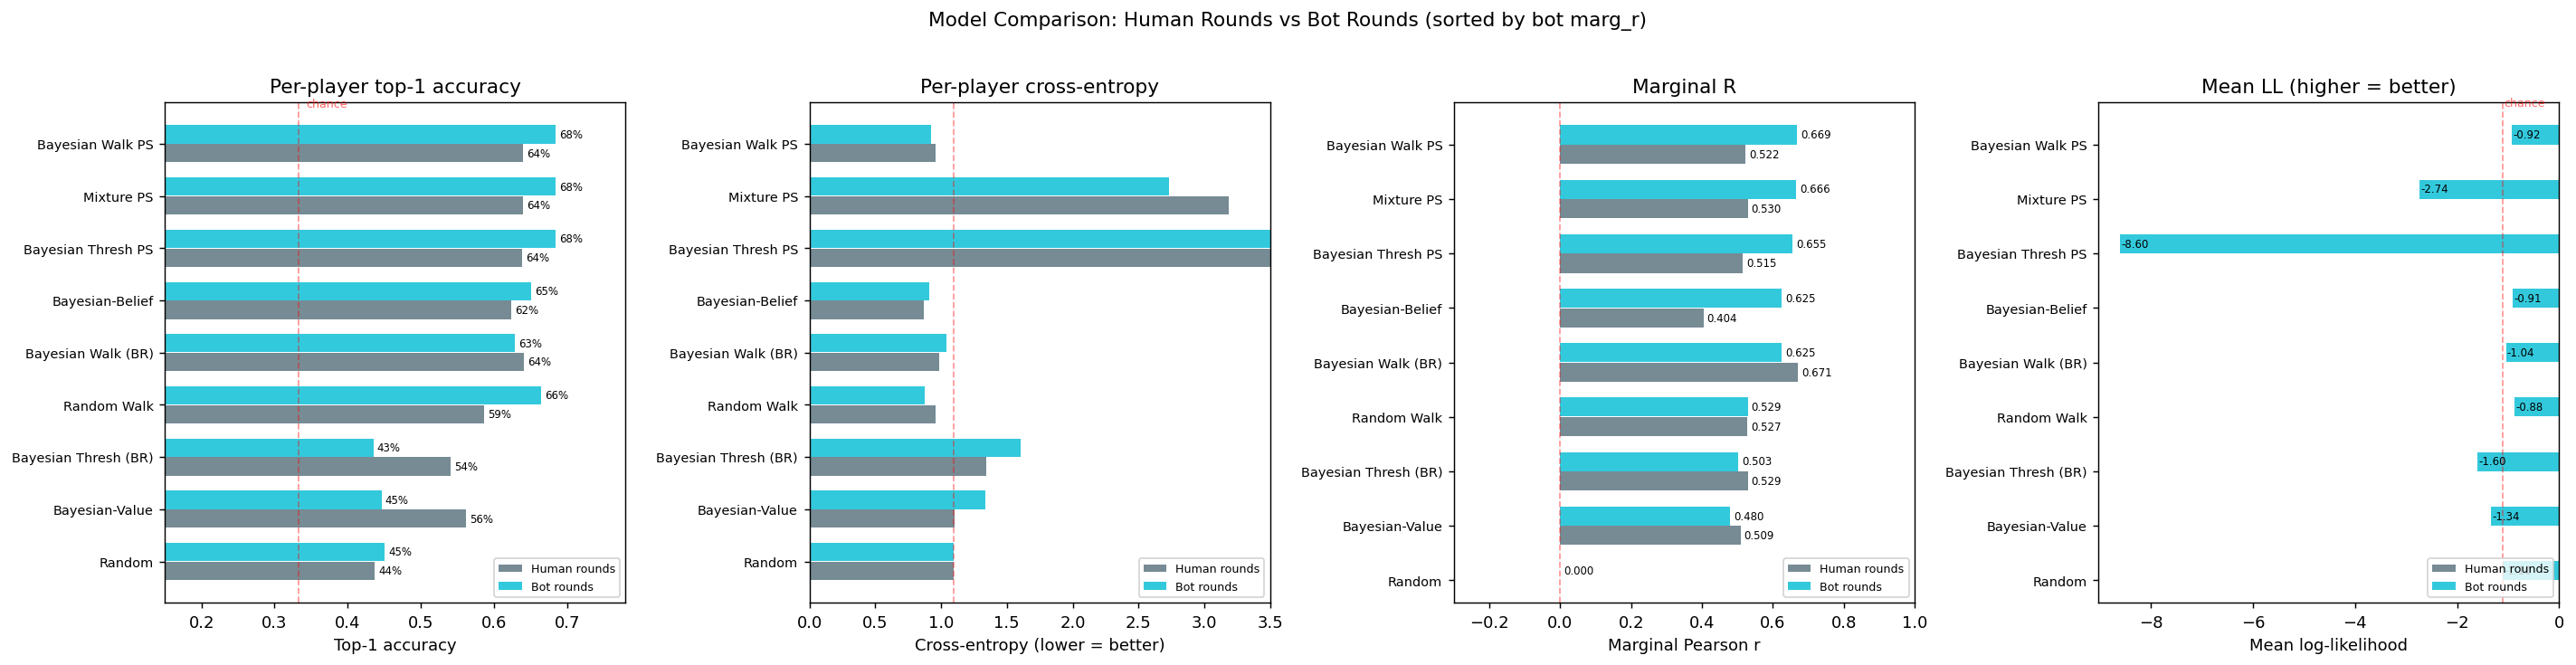


=== Model Comparison Table ===

Model                   Bot acc  Hum acc   Bot CE   Hum CE   Bot mr   Hum mr   Bot LL   Hum LL
------------------------------------------------------------------------------------------------
  Bayesian Walk PS       68.4%   64.0%    0.924    0.956   0.669   0.522   -0.92     nan
  Mixture PS             68.4%   64.0%    2.735    3.183   0.666   0.530   -2.74     nan
  Bayesian Thresh PS     68.4%   63.9%    8.598   11.884   0.655   0.515   -8.60     nan
  Bayesian-Belief        65.1%   62.3%    0.910    0.871   0.625   0.404   -0.91     nan
  Bayesian Walk (BR)     62.8%   64.1%    1.042    0.987   0.625   0.671   -1.04     nan
  Random Walk            66.5%   58.7%    0.877    0.959   0.529   0.527   -0.88     nan
  Bayesian Thresh (BR)   43.5%   54.1%    1.605    1.342   0.503   0.529   -1.60     nan
  Bayesian-Value         44.6%   56.2%    1.336    1.102   0.480   0.509   -1.34     nan
  Random                 45.0%   43.7%    1.099    1.099   0.00

In [7]:
# === Figure 2: Model comparison (accuracy, CE, marg_r, mean_ll) ===

fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))

rt = pd.DataFrame(results_table).set_index('Model')
order = rt.sort_values('bot_marg_r', ascending=True).index.tolist()
y_pos = np.arange(len(order))

# --- Panel 1: Top-1 accuracy ---
ax = axes[0]
hum_vals = [rt.loc[m, 'hum_acc'] for m in order]
bot_vals = [rt.loc[m, 'bot_acc'] for m in order]
ax.barh(y_pos - 0.18, hum_vals, 0.35, label='Human rounds', color='#546E7A', alpha=0.8)
ax.barh(y_pos + 0.18, bot_vals, 0.35, label='Bot rounds', color='#00BCD4', alpha=0.8)
ax.set_yticks(y_pos); ax.set_yticklabels(order, fontsize=8)
ax.set_xlabel('Top-1 accuracy')
ax.set_title('Per-player top-1 accuracy')
ax.axvline(x=1/3, color='r', linestyle='--', alpha=0.4, linewidth=1)
ax.text(1/3 + 0.01, len(order) - 0.3, 'chance', fontsize=7, color='r', alpha=0.6)
ax.legend(fontsize=7, loc='lower right')
ax.set_xlim(0.15, 0.78)
for i, (hv, bv) in enumerate(zip(hum_vals, bot_vals)):
    ax.text(hv + 0.005, i - 0.18, f'{hv:.0%}', va='center', fontsize=6.5)
    ax.text(bv + 0.005, i + 0.18, f'{bv:.0%}', va='center', fontsize=6.5)

# --- Panel 2: Cross-entropy ---
ax = axes[1]
hum_ce = [rt.loc[m, 'hum_ce'] for m in order]
bot_ce = [rt.loc[m, 'bot_ce'] for m in order]
ax.barh(y_pos - 0.18, hum_ce, 0.35, label='Human rounds', color='#546E7A', alpha=0.8)
ax.barh(y_pos + 0.18, bot_ce, 0.35, label='Bot rounds', color='#00BCD4', alpha=0.8)
ax.set_yticks(y_pos); ax.set_yticklabels(order, fontsize=8)
ax.set_xlabel('Cross-entropy (lower = better)')
ax.set_title('Per-player cross-entropy')
ax.axvline(x=np.log(3), color='r', linestyle='--', alpha=0.4, linewidth=1)
ax.legend(fontsize=7, loc='lower right')
ax.set_xlim(0, 3.5)

# --- Panel 3: Marginal R ---
ax = axes[2]
hum_mr = [rt.loc[m, 'hum_marg_r'] for m in order]
bot_mr = [rt.loc[m, 'bot_marg_r'] for m in order]
ax.barh(y_pos - 0.18, hum_mr, 0.35, label='Human rounds', color='#546E7A', alpha=0.8)
ax.barh(y_pos + 0.18, bot_mr, 0.35, label='Bot rounds', color='#00BCD4', alpha=0.8)
ax.set_yticks(y_pos); ax.set_yticklabels(order, fontsize=8)
ax.set_xlabel('Marginal Pearson r')
ax.set_title('Marginal R')
ax.axvline(x=0, color='r', linestyle='--', alpha=0.4, linewidth=1)
ax.legend(fontsize=7, loc='lower right')
ax.set_xlim(-0.3, 1.0)
for i, (hv, bv) in enumerate(zip(hum_mr, bot_mr)):
    ax.text(max(hv, 0) + 0.01, i - 0.18, f'{hv:.3f}', va='center', fontsize=6.5)
    ax.text(max(bv, 0) + 0.01, i + 0.18, f'{bv:.3f}', va='center', fontsize=6.5)

# --- Panel 4: Mean LL ---
ax = axes[3]
hum_ll = [rt.loc[m, 'hum_mean_ll'] for m in order]
bot_ll = [rt.loc[m, 'bot_mean_ll'] for m in order]
ax.barh(y_pos - 0.18, hum_ll, 0.35, label='Human rounds', color='#546E7A', alpha=0.8)
ax.barh(y_pos + 0.18, bot_ll, 0.35, label='Bot rounds', color='#00BCD4', alpha=0.8)
ax.set_yticks(y_pos); ax.set_yticklabels(order, fontsize=8)
ax.set_xlabel('Mean log-likelihood')
ax.set_title('Mean LL (higher = better)')
ax.axvline(x=np.log(1/3), color='r', linestyle='--', alpha=0.4, linewidth=1)
ax.text(np.log(1/3) + 0.02, len(order) - 0.3, 'chance', fontsize=7, color='r', alpha=0.6)
ax.legend(fontsize=7, loc='lower right')
for i, (hv, bv) in enumerate(zip(hum_ll, bot_ll)):
    ax.text(hv + 0.02, i - 0.18, f'{hv:.2f}', va='center', fontsize=6.5)
    ax.text(bv + 0.02, i + 0.18, f'{bv:.2f}', va='center', fontsize=6.5)

plt.suptitle('Model Comparison: Human Rounds vs Bot Rounds (sorted by bot marg_r)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig2_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print table
print('\n=== Model Comparison Table ===\n')
print(f'{"Model":<22} {"Bot acc":>8} {"Hum acc":>8} {"Bot CE":>8} {"Hum CE":>8} {"Bot mr":>8} {"Hum mr":>8} {"Bot LL":>8} {"Hum LL":>8}')
print('-' * 96)
for m in rt.sort_values('bot_marg_r', ascending=False).index:
    r = rt.loc[m]
    print(f'  {m:<20} {r["bot_acc"]:>7.1%} {r["hum_acc"]:>7.1%} {r["bot_ce"]:>8.3f} {r["hum_ce"]:>8.3f} {r["bot_marg_r"]:>7.3f} {r["hum_marg_r"]:>7.3f} {r["bot_mean_ll"]:>7.2f} {r["hum_mean_ll"]:>7.2f}')
print(f'\n  Chance: 33.3% acc, {np.log(3):.3f} CE, 0.000 marg_r, {np.log(1/3):.3f} LL')

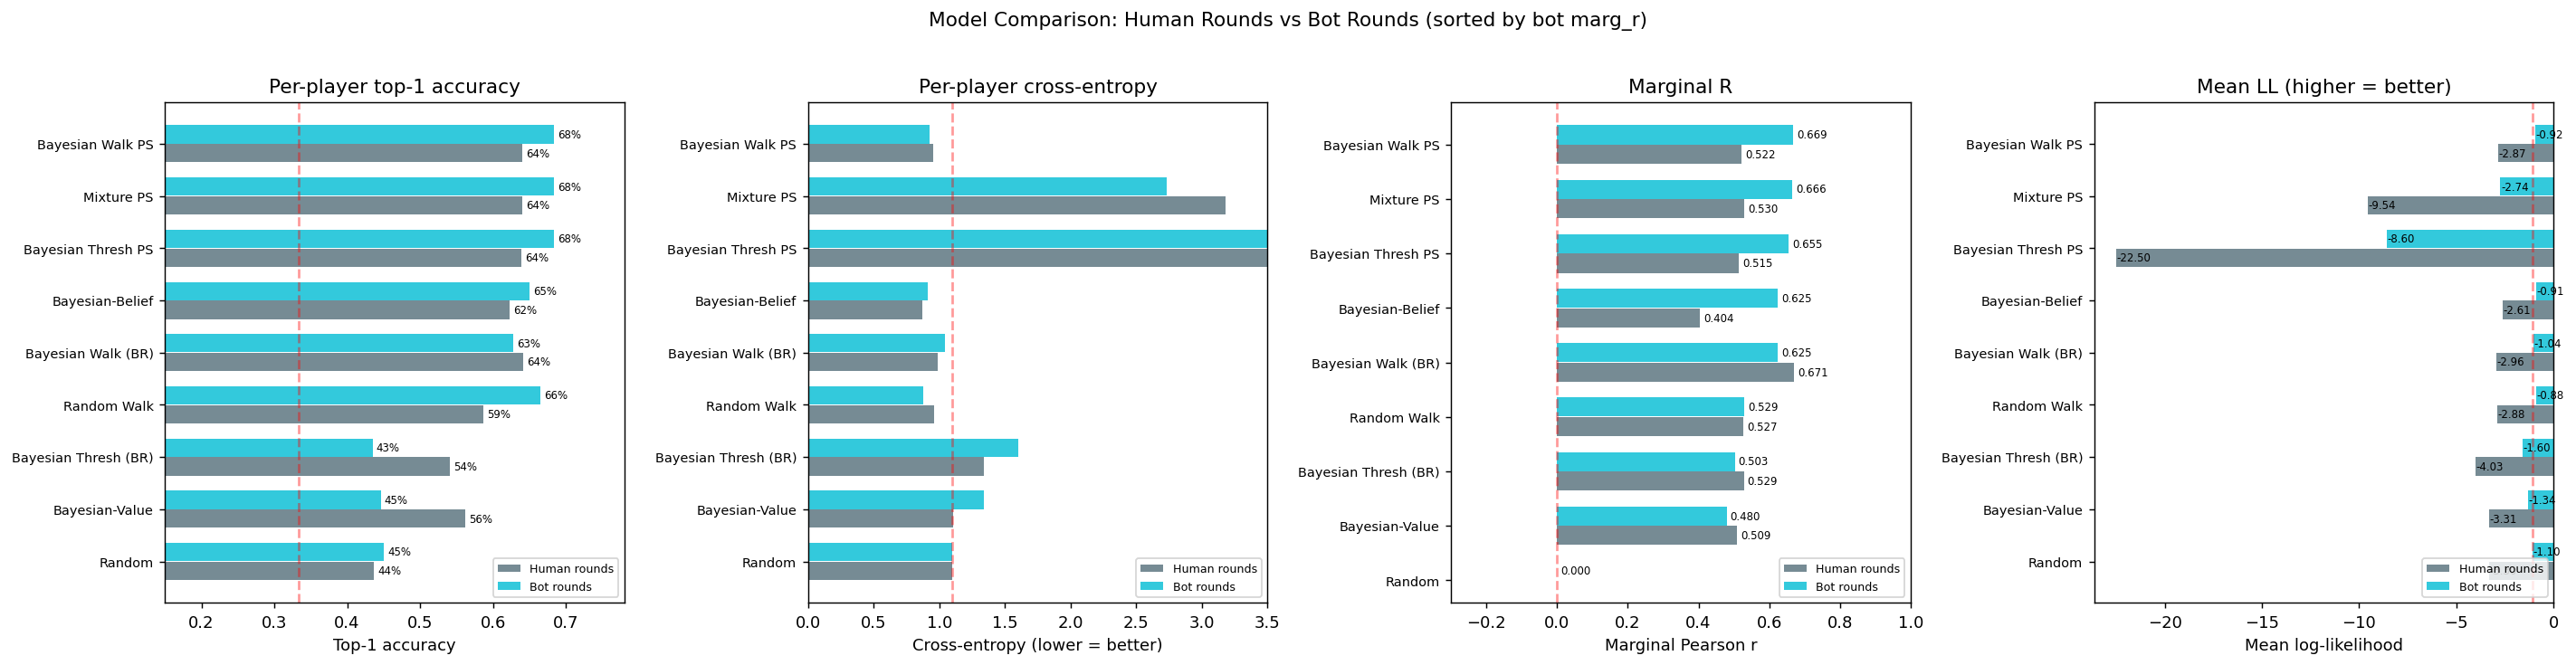


=== Model Comparison Table ===

Model                   Bot acc  Hum acc   Bot CE   Hum CE   Bot mr   Hum mr   Bot LL   Hum LL
------------------------------------------------------------------------------------------------
  Bayesian Walk PS       68.4%   64.0%    0.924    0.956   0.669   0.522   -0.92   -2.87
  Mixture PS             68.4%   64.0%    2.735    3.183   0.666   0.530   -2.74   -9.54
  Bayesian Thresh PS     68.4%   63.9%    8.598   11.884   0.655   0.515   -8.60  -22.50
  Bayesian-Belief        65.1%   62.3%    0.910    0.871   0.625   0.404   -0.91   -2.61
  Bayesian Walk (BR)     62.8%   64.1%    1.042    0.987   0.625   0.671   -1.04   -2.96
  Random Walk            66.5%   58.7%    0.877    0.959   0.529   0.527   -0.88   -2.88
  Bayesian Thresh (BR)   43.5%   54.1%    1.605    1.342   0.503   0.529   -1.60   -4.03
  Bayesian-Value         44.6%   56.2%    1.336    1.102   0.480   0.509   -1.34   -3.31
  Random                 45.0%   43.7%    1.099    1.099   0.00

In [9]:
# === Figure 2 (re-run with fixed mean_ll) ===

fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))

rt = pd.DataFrame(results_table).set_index('Model')
order = rt.sort_values('bot_marg_r', ascending=True).index.tolist()
y_pos = np.arange(len(order))

# --- Panel 1: Top-1 accuracy ---
ax = axes[0]
hum_vals = [rt.loc[m, 'hum_acc'] for m in order]
bot_vals = [rt.loc[m, 'bot_acc'] for m in order]
ax.barh(y_pos - 0.18, hum_vals, 0.35, label='Human rounds', color='#546E7A', alpha=0.8)
ax.barh(y_pos + 0.18, bot_vals, 0.35, label='Bot rounds', color='#00BCD4', alpha=0.8)
ax.set_yticks(y_pos); ax.set_yticklabels(order, fontsize=8)
ax.set_xlabel('Top-1 accuracy'); ax.set_title('Per-player top-1 accuracy')
ax.axvline(x=1/3, color='r', linestyle='--', alpha=0.4)
ax.legend(fontsize=7, loc='lower right'); ax.set_xlim(0.15, 0.78)
for i, (hv, bv) in enumerate(zip(hum_vals, bot_vals)):
    ax.text(hv + 0.005, i - 0.18, f'{hv:.0%}', va='center', fontsize=6.5)
    ax.text(bv + 0.005, i + 0.18, f'{bv:.0%}', va='center', fontsize=6.5)

# --- Panel 2: Cross-entropy ---
ax = axes[1]
hum_ce = [rt.loc[m, 'hum_ce'] for m in order]
bot_ce = [rt.loc[m, 'bot_ce'] for m in order]
ax.barh(y_pos - 0.18, hum_ce, 0.35, label='Human rounds', color='#546E7A', alpha=0.8)
ax.barh(y_pos + 0.18, bot_ce, 0.35, label='Bot rounds', color='#00BCD4', alpha=0.8)
ax.set_yticks(y_pos); ax.set_yticklabels(order, fontsize=8)
ax.set_xlabel('Cross-entropy (lower = better)'); ax.set_title('Per-player cross-entropy')
ax.axvline(x=np.log(3), color='r', linestyle='--', alpha=0.4)
ax.legend(fontsize=7, loc='lower right'); ax.set_xlim(0, 3.5)

# --- Panel 3: Marginal R ---
ax = axes[2]
hum_mr = [rt.loc[m, 'hum_marg_r'] for m in order]
bot_mr = [rt.loc[m, 'bot_marg_r'] for m in order]
ax.barh(y_pos - 0.18, hum_mr, 0.35, label='Human rounds', color='#546E7A', alpha=0.8)
ax.barh(y_pos + 0.18, bot_mr, 0.35, label='Bot rounds', color='#00BCD4', alpha=0.8)
ax.set_yticks(y_pos); ax.set_yticklabels(order, fontsize=8)
ax.set_xlabel('Marginal Pearson r'); ax.set_title('Marginal R')
ax.axvline(x=0, color='r', linestyle='--', alpha=0.4)
ax.legend(fontsize=7, loc='lower right'); ax.set_xlim(-0.3, 1.0)
for i, (hv, bv) in enumerate(zip(hum_mr, bot_mr)):
    ax.text(max(hv, 0) + 0.01, i - 0.18, f'{hv:.3f}', va='center', fontsize=6.5)
    ax.text(max(bv, 0) + 0.01, i + 0.18, f'{bv:.3f}', va='center', fontsize=6.5)

# --- Panel 4: Mean LL ---
ax = axes[3]
hum_ll = [rt.loc[m, 'hum_mean_ll'] for m in order]
bot_ll = [rt.loc[m, 'bot_mean_ll'] for m in order]
ax.barh(y_pos - 0.18, hum_ll, 0.35, label='Human rounds', color='#546E7A', alpha=0.8)
ax.barh(y_pos + 0.18, bot_ll, 0.35, label='Bot rounds', color='#00BCD4', alpha=0.8)
ax.set_yticks(y_pos); ax.set_yticklabels(order, fontsize=8)
ax.set_xlabel('Mean log-likelihood'); ax.set_title('Mean LL (higher = better)')
ax.axvline(x=np.log(1/3), color='r', linestyle='--', alpha=0.4)
ax.legend(fontsize=7, loc='lower right')
for i, (hv, bv) in enumerate(zip(hum_ll, bot_ll)):
    ax.text(hv + 0.02, i - 0.18, f'{hv:.2f}', va='center', fontsize=6.5)
    ax.text(bv + 0.02, i + 0.18, f'{bv:.2f}', va='center', fontsize=6.5)

plt.suptitle('Model Comparison: Human Rounds vs Bot Rounds (sorted by bot marg_r)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig2_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Print table
print('\n=== Model Comparison Table ===\n')
print(f'{"Model":<22} {"Bot acc":>8} {"Hum acc":>8} {"Bot CE":>8} {"Hum CE":>8} {"Bot mr":>8} {"Hum mr":>8} {"Bot LL":>8} {"Hum LL":>8}')
print('-' * 96)
for m in rt.sort_values('bot_marg_r', ascending=False).index:
    r = rt.loc[m]
    print(f'  {m:<20} {r["bot_acc"]:>7.1%} {r["hum_acc"]:>7.1%} {r["bot_ce"]:>8.3f} {r["hum_ce"]:>8.3f} {r["bot_marg_r"]:>7.3f} {r["hum_marg_r"]:>7.3f} {r["bot_mean_ll"]:>7.2f} {r["hum_mean_ll"]:>7.2f}')
print(f'\n  Chance: 33.3% acc, {np.log(3):.3f} CE, 0.000 marg_r, {np.log(1/3):.3f} LL')

## 3. Why does Bayesian-Value fail on bot rounds?

Bayesian-Value uses the MDP value function and predicts the role with highest expected value. It *should* capture deviation to the optimal role. But it drops from 56% to 45% accuracy on bot rounds. Two problems:
1. The model doesn't know bots have fixed roles — it treats all 3 players as uncertain.
2. The value-optimal role often disagrees with both deviate-optimal and what humans actually do.

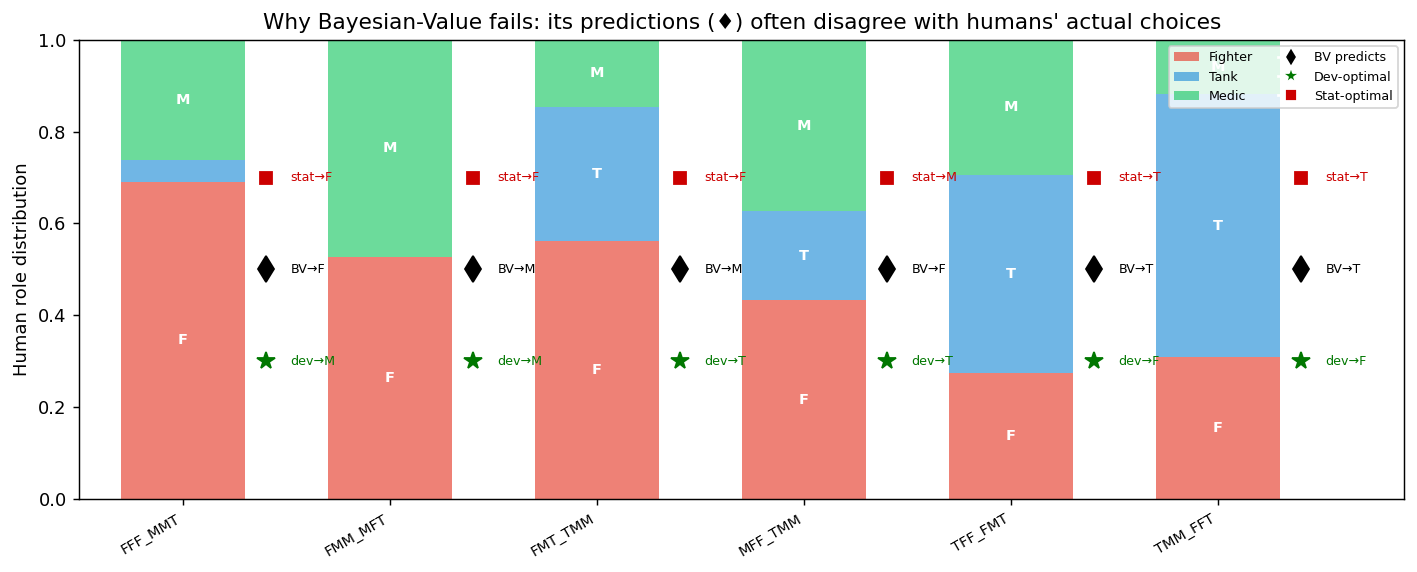


=== Bayesian-Value Prediction vs Reality ===

        Stat-opt Dev-opt BV predicts Human fav BV==Human   F%   T%   M%
Config                                                                 
FFF_MMT        F       M           F         F         ✓  69%   5%  26%
FMM_MFT        F       M           M         F         ✗  53%   0%  47%
FMT_TMM        F       T           M         F         ✗  56%  29%  15%
MFF_TMM        M       T           F         F         ✓  43%  19%  37%
TFF_FMT        T       F           T         T         ✓  27%  43%  29%
TMM_FFT        T       F           T         T         ✓  31%  57%  12%


In [10]:
# === Figure 3: Why Bayesian-Value fails ===

fig, ax = plt.subplots(figsize=(11, 4.5))

configs = sorted(set(r['env_id'] for r in bot_team_records))
x = np.arange(len(configs))
bar_w = 0.2

p_bv = params['bv']['aggregate_tuned']
bv_fn = make_bayesian_value(p_bv['tau_prior'], p_bv['tau_softmax'], p_bv['epsilon'])
role_colors = {'F': '#e74c3c', 'T': '#3498db', 'M': '#2ecc71'}

table_rows = []
for i, odr_id in enumerate(configs):
    recs = [r for r in bot_team_records if r['env_id'] == odr_id]
    stat_opt, dev_opt = odr_id.split('_')
    hp = recs[0]['human_position']
    
    # Value-optimal: what BV predicts at stage 0
    preds = bv_fn(recs[0])
    bv_marg = np.zeros(3)
    for combo, prob in preds[0]['predicted_dist'].items():
        bv_marg[ROLE_CHAR_TO_IDX[combo[hp]]] += prob
    bv_marg /= bv_marg.sum()
    bv_role = ROLE_SHORT[np.argmax(bv_marg)]
    
    # Human distribution
    roles = [combo[hp] for r in recs for combo in r['stage_roles']]
    human_dist = {role: roles.count(role)/len(roles) for role in ['F', 'T', 'M']}
    human_fav = Counter(roles).most_common(1)[0][0]
    
    table_rows.append({
        'Config': odr_id, 'Stat-opt': stat_opt[0], 'Dev-opt': dev_opt[0],
        'BV predicts': bv_role, 'Human fav': human_fav,
        'BV==Human': '✓' if bv_role == human_fav else '✗',
        'F%': f"{human_dist['F']:.0%}", 'T%': f"{human_dist['T']:.0%}", 'M%': f"{human_dist['M']:.0%}",
    })

    # Stacked bar of human role dist
    bottom = 0
    for role in ['F', 'T', 'M']:
        h = human_dist[role]
        ax.bar(i, h, bar_w * 3, bottom=bottom, color=role_colors[role], alpha=0.7)
        if h > 0.08:
            ax.text(i, bottom + h/2, f'{role}', ha='center', va='center', fontsize=8, fontweight='bold', color='white')
        bottom += h
    
    ax.plot(i + 0.4, 0.5, marker='d', color='black', markersize=10, zorder=5)
    ax.text(i + 0.52, 0.5, f'BV→{bv_role}', fontsize=7, va='center')
    ax.plot(i + 0.4, 0.3, marker='*', color='#007700', markersize=10, zorder=5)
    ax.text(i + 0.52, 0.3, f'dev→{dev_opt[0]}', fontsize=7, va='center', color='#007700')
    ax.plot(i + 0.4, 0.7, marker='s', color='#cc0000', markersize=7, zorder=5)
    ax.text(i + 0.52, 0.7, f'stat→{stat_opt[0]}', fontsize=7, va='center', color='#cc0000')

ax.set_xticks(x)
ax.set_xticklabels(configs, fontsize=8, rotation=30, ha='right')
ax.set_ylabel('Human role distribution')
ax.set_title("Why Bayesian-Value fails: its predictions (♦) often disagree with humans' actual choices")
ax.set_ylim(0, 1.0); ax.set_xlim(-0.5, len(configs) - 0.1)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legend = [
    Patch(facecolor='#e74c3c', alpha=0.7, label='Fighter'),
    Patch(facecolor='#3498db', alpha=0.7, label='Tank'),
    Patch(facecolor='#2ecc71', alpha=0.7, label='Medic'),
    Line2D([0],[0], marker='d', color='w', markerfacecolor='black', markersize=8, label='BV predicts'),
    Line2D([0],[0], marker='*', color='w', markerfacecolor='#007700', markersize=10, label='Dev-optimal'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='#cc0000', markersize=7, label='Stat-optimal'),
]
ax.legend(handles=legend, fontsize=7, loc='upper right', ncol=2)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig3_bayesian_value_failure.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Bayesian-Value Prediction vs Reality ===\n")
tdf = pd.DataFrame(table_rows).set_index('Config')
print(tdf.to_string())

## Summary

**Q1: What do humans do in bot rounds?**
- Humans mostly stick to stat-optimal (52%) rather than deviating to true optimal (30%).
- 33% stat-adherent, 24% deviators, 43% mixed/explorers.

**Q2: Which models explain this? (with Bhavyesh's tuned params)**
- **Bayesian Walk PS** leads on bot marg_r (0.669) and bot accuracy (68.4%).
- **Mixture PS** and **Bayesian Thresh PS** also strong (marg_r 0.666, 0.655).
- **Bayesian-Belief** (tuned: τ=2.533, ε=0.540) achieves 65.1% bot accuracy, 0.625 marg_r, and best bot mean_ll (-0.91).
- **Random Walk** competitive at 66.5% accuracy, 0.529 marg_r.
- **Bayesian Walk (BR)** best on human marg_r (0.671) but drops on bot rounds (0.625).

**Q3: Why does Bayesian-Value fail?**
- Drops from 56% (human) to 45% (bot) accuracy — barely above chance.
- In 2/6 configs (FMM_MFT, FMT_TMM), BV predicts Medic but humans choose Fighter.
- BV assumes players optimize for game value, but in bot rounds most humans follow their stat prior.

**Key update vs 04-02:** Added Bayesian Thresh PS and Bayesian Thresh (BR) models. Updated Bayesian-Belief to use Bhavyesh's tuned params instead of default (2.0, 0.5). Added mean_ll as a metric alongside accuracy/CE/marg_r.